Connecting to HYCOM model server...
Data loaded and calculated! Plotting...


/Users/inside/miniforge3/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Users/inside/miniforge3/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


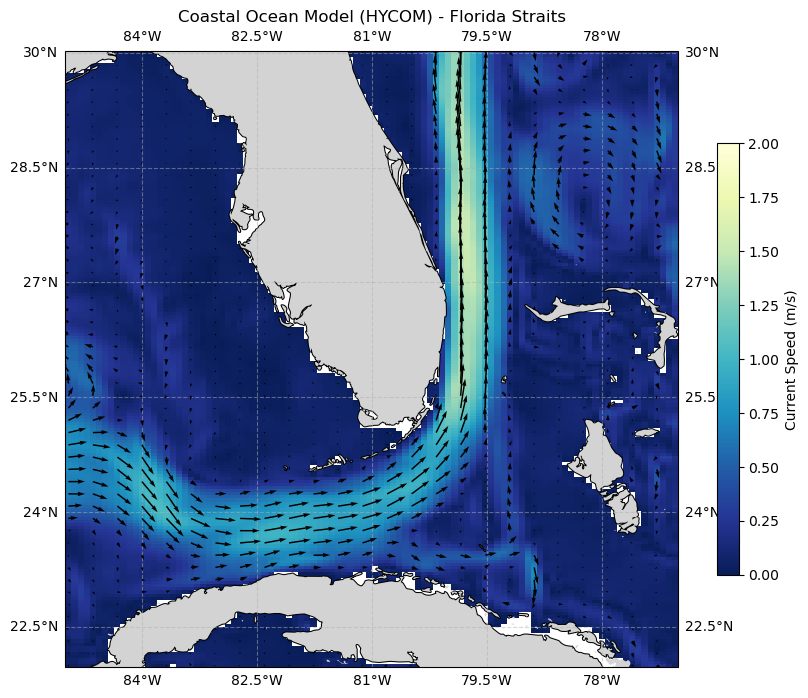

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Connecting to the HYCOM model via OPeNDAP
url = "https://tds.hycom.org/thredds/dodsC/GLBy0.08/expt_93.0"
print("Connecting to HYCOM model server...")
ds = xr.open_dataset(url, decode_times=False)

# Slicing the data
model_subset = ds.sel(
    depth=0,
    lat=slice(22, 30),
    lon=slice(275, 283)
).isel(time=0) 

# Extracting the u (east-west) and v (north-south) velocities
u_velocity = model_subset.water_u
v_velocity = model_subset.water_v

# Calculating total current speed
speed = np.sqrt(u_velocity**2 + v_velocity**2)

print("Data loaded and calculated")

# Seting up the map figure
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE, linewidth=1.5)
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)

# Ploting the current speed as the background color
pcm = ax.pcolormesh(
    speed.lon, speed.lat, speed,
    transform=ccrs.PlateCarree(),
    cmap='YlGnBu_r',
    vmin=0, vmax=2.0, zorder=1
)

# Overlaying the velocity vectors (arrows) using quiver
u_sub = u_velocity[::4, ::4]
v_sub = v_velocity[::4, ::4]

ax.quiver(
    u_sub.lon, u_sub.lat,
    u_sub.values, v_sub.values,
    transform=ccrs.PlateCarree(),
    scale=25,
    color='black',
    zorder=3
)

# Adding colorbar and labels
cbar = plt.colorbar(pcm, ax=ax, orientation='vertical', pad=0.05, shrink=0.7)
cbar.set_label('Current Speed (m/s)')
plt.title('Coastal Ocean Model (HYCOM) - Florida Straits')

plt.savefig("../figures/coastal_model_currents.png", dpi=300, bbox_inches='tight')
plt.show()